<a href="https://colab.research.google.com/github/lsuruDilshan/SAMA_Block_Forest_Segmentation/blob/main/SAMA_Block_Forest_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **01. Enable GPU check**

In [ ]:
!nvidia-smi

Tue Jul  7 09:02:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **02. Clone the official SAMA-UNet repo**

In [ ]:
%cd /content

!rm -rf SAMA-UNet

!git clone https://github.com/sqbqamar/SAMA-UNet.git

%cd /content/SAMA-UNet

!ls

/content
Cloning into 'SAMA-UNet'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 63 (delta 18), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 943.58 KiB | 3.69 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/SAMA-UNet
config.txt     model.py    README.md	     results   utils.py
dataloader.py  predict.py  requirements.txt  train.py


## **03. Install requirements**

In [ ]:
%cd /content/SAMA-UNet

!pip install -r requirements.txt

/content/SAMA-UNet
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 27.5 MB/s eta 0:00:00


## **04. Inspect model classes**

In [ ]:
%cd /content/SAMA-UNet

!grep -n "class " model.py

/content/SAMA-UNet
18:class DepthwiseSeparableConv(nn.Module):
34:class LocallyEnhancedPE(nn.Module):
45:class DifferentialAttention(nn.Module):
88:class DifferentialAggregatedAttention(nn.Module):
138:class SAMA_Block(nn.Module):
232:class SSM2D(nn.Module):
281:class CausalResonanceMultiScaleModule(nn.Module):
340:class PatchEmbedding(nn.Module):
360:class DownSampling(nn.Module):
372:class UpSampling(nn.Module):
384:class ResidualConvBlock(nn.Module):
412:class SAMA_UNet(nn.Module):


## **05. Inspect model constructors**

In [ ]:
%cd /content/SAMA-UNet

!grep -n "def __init__" model.py



/content/SAMA-UNet
20:    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
36:    def __init__(self, dim, kernel_size=3):
50:    def __init__(self, dim, num_heads=8, qkv_bias=False, lambda_init=0.8):
93:    def __init__(self, dim, num_heads=8, window_size=7, is_local=True):
143:    def __init__(self, dim, num_heads=8, mlp_ratio=4., window_size=7):
237:    def __init__(self, dim, d_state=16):
286:    def __init__(self, dim, d_state=16):
344:    def __init__(self, in_channels=3, embed_dim=96, patch_size=4, stride=4):
362:    def __init__(self, in_channels, out_channels):
374:    def __init__(self, in_channels, out_channels):
386:    def __init__(self, in_channels, out_channels):
417:    def __init__(self, 


## **06. Import the official SAMA-UNet and smoke test**

In [ ]:
from pathlib import Path
import os
import sys
import shutil
import subprocess
import importlib.util

import torch


# ============================================================
# 1. RESTORE OFFICIAL SAMA-UNET REPOSITORY
# ============================================================

REPO_DIR = Path("/content/SAMA-UNet")
MODEL_FILE = REPO_DIR / "model.py"


if not MODEL_FILE.exists():
    print("model.py not found. Re-cloning the repository...")

    if REPO_DIR.exists():
        shutil.rmtree(REPO_DIR)

    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/sqbqamar/SAMA-UNet.git",
            str(REPO_DIR),
        ],
        check=True,
    )

else:
    print("Repository and model.py already exist.")


# ============================================================
# 2. CONFIRM FILES
# ============================================================

os.chdir(REPO_DIR)

print("\nCurrent working directory:")
print(os.getcwd())

print("\nRepository files:")
for item in sorted(REPO_DIR.iterdir()):
    print("-", item.name)


if not MODEL_FILE.exists():
    raise FileNotFoundError(
        f"model.py still not found at:\n{MODEL_FILE}"
    )


# ============================================================
# 3. IMPORT SAMA_Block DIRECTLY FROM model.py
# ============================================================

sys.path.insert(
    0,
    str(REPO_DIR),
)

spec = importlib.util.spec_from_file_location(
    "sama_official_model",
    MODEL_FILE,
)

sama_official_model = importlib.util.module_from_spec(
    spec
)

spec.loader.exec_module(
    sama_official_model
)

SAMA_Block = sama_official_model.SAMA_Block


print("\nSAMA_Block imported successfully.")


# ============================================================
# 4. TEST THE OFFICIAL SAMA BLOCK
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


sama_block = SAMA_Block(
    dim=512,
    num_heads=8,
).to(DEVICE)


dummy_feature = torch.randn(
    1,
    512,
    32,
    32,
    device=DEVICE,
)


print("\nDevice:", DEVICE)
print("Input feature shape:", dummy_feature.shape)


with torch.inference_mode():
    output_feature = sama_block(
        dummy_feature
    )


print("Output feature shape:", output_feature.shape)


sama_block_parameters = sum(
    parameter.numel()
    for parameter in sama_block.parameters()
)


print(
    "SAMA block parameters:",
    f"{sama_block_parameters:,}",
)


del dummy_feature
del output_feature
del sama_block

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Repository and model.py already exist.

Current working directory:
/content/SAMA-UNet

Repository files:
- .git
- README.md
- config.txt
- dataloader.py
- model.py
- predict.py
- requirements.txt
- results
- train.py
- utils.py

SAMA_Block imported successfully.

Device: cuda
Input feature shape: torch.Size([1, 512, 32, 32])
Output feature shape: torch.Size([1, 512, 32, 32])
SAMA block parameters: 3,817,986


## **07. Mount Drive and restore experiment configuration**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import torch


# ============================================================
# ORIGINAL DATASET
# ============================================================

DRIVE_DATASET_ZIP = Path(
    "/content/drive/MyDrive/ForestResearch/Unet-forest.zip"
)

RUNTIME_EXTRACTION_DIR = Path(
    "/content/dataset/unet_forest_extracted"
)

DATASET_DIR = Path(
    "/content/dataset/unet_forest_extracted/Unet-forest"
)


# ============================================================
# OUTPUT FOLDER FOR THIS MODEL
# ============================================================

EXPERIMENT_NAME = "SAMA_Block_Enhanced_UNet_Original"

DRIVE_OUTPUT_DIR = Path(
    f"/content/drive/MyDrive/ForestResearch/Results/{EXPERIMENT_NAME}"
)

CHECKPOINT_DIR = DRIVE_OUTPUT_DIR / "checkpoints"
FIGURE_DIR = DRIVE_OUTPUT_DIR / "figures"
PREDICTION_DIR = DRIVE_OUTPUT_DIR / "predictions"
LOG_DIR = DRIVE_OUTPUT_DIR / "logs"


# ============================================================
# IMAGE AND MASK CONFIGURATION
# ============================================================

IN_CHANNELS = 3
BAND_INDICES = [1, 2, 3]
RGB_DISPLAY_INDICES = [0, 1, 2]

FOREST_CLASS_VALUE = 1
BACKGROUND_CLASS_VALUE = 2

IMAGE_SIZE = 512
NUM_CLASSES = 1


# ============================================================
# MODEL CONFIGURATION
# ============================================================

BASE_CHANNELS = 32


# ============================================================
# TRAINING CONFIGURATION
# ============================================================

SEED = 42

BATCH_SIZE = 2
ACCUMULATION_STEPS = 2

NUM_EPOCHS = 100

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

BCE_WEIGHT = 0.5
DICE_WEIGHT = 0.5

NUM_WORKERS = 2

EARLY_STOPPING_PATIENCE = 15
LR_PATIENCE = 5
LR_REDUCTION_FACTOR = 0.5

GRADIENT_CLIP_NORM = 1.0
THRESHOLD = 0.50


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"


for folder in [
    DRIVE_OUTPUT_DIR,
    CHECKPOINT_DIR,
    FIGURE_DIR,
    PREDICTION_DIR,
    LOG_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


print("=" * 70)
print("SAMA BLOCK EXPERIMENT CONFIGURATION")
print("=" * 70)

print("Dataset ZIP exists:", DRIVE_DATASET_ZIP.exists())
print("Dataset ZIP:", DRIVE_DATASET_ZIP)

print("\nDataset directory:")
print(DATASET_DIR)

print("\nOutput directory:")
print(DRIVE_OUTPUT_DIR)

print("\nDevice:", DEVICE)
print("Input channels:", IN_CHANNELS)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Effective batch size:", BATCH_SIZE * ACCUMULATION_STEPS)

SAMA BLOCK EXPERIMENT CONFIGURATION
Dataset ZIP exists: True
Dataset ZIP: /content/drive/MyDrive/ForestResearch/Unet-forest.zip

Dataset directory:
/content/dataset/unet_forest_extracted/Unet-forest

Output directory:
/content/drive/MyDrive/ForestResearch/Results/SAMA_Block_Enhanced_UNet_Original

Device: cuda
Input channels: 3
Image size: 512
Batch size: 2
Effective batch size: 4


## **08. Extract dataset ZIP**

In [ ]:
import zipfile
import shutil


FORCE_REEXTRACT = False


if not DRIVE_DATASET_ZIP.exists():
    raise FileNotFoundError(
        f"Dataset ZIP was not found:\n{DRIVE_DATASET_ZIP}"
    )


if FORCE_REEXTRACT and RUNTIME_EXTRACTION_DIR.exists():
    shutil.rmtree(RUNTIME_EXTRACTION_DIR)


if not DATASET_DIR.exists():
    print("Extracting dataset...")

    RUNTIME_EXTRACTION_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    with zipfile.ZipFile(DRIVE_DATASET_ZIP, "r") as zip_reference:
        zip_reference.extractall(RUNTIME_EXTRACTION_DIR)

    print("Extraction completed.")

else:
    print("Dataset already extracted.")


print("\nDataset root exists:")
print(DATASET_DIR.exists())

print("\nDataset contents:")

for item in sorted(DATASET_DIR.iterdir()):
    print("-", item.name)

Extracting dataset...
Extraction completed.

Dataset root exists:
True

Dataset contents:
- image
- label
- teste
- val


## **09. Define train, validation and test folders**

In [ ]:
TRAIN_IMAGE_DIR = DATASET_DIR / "image"
TRAIN_MASK_DIR = DATASET_DIR / "label"

VAL_IMAGE_DIR = DATASET_DIR / "val" / "images"
VAL_MASK_DIR = DATASET_DIR / "val" / "masks"

TEST_IMAGE_DIR = DATASET_DIR / "teste" / "image"
TEST_MASK_DIR = DATASET_DIR / "teste" / "mask"


required_folders = [
    TRAIN_IMAGE_DIR,
    TRAIN_MASK_DIR,
    VAL_IMAGE_DIR,
    VAL_MASK_DIR,
    TEST_IMAGE_DIR,
    TEST_MASK_DIR,
]


for folder in required_folders:
    print(folder, "->", folder.exists())

    if not folder.exists():
        raise FileNotFoundError(
            f"Missing required folder:\n{folder}"
        )

/content/dataset/unet_forest_extracted/Unet-forest/image -> True
/content/dataset/unet_forest_extracted/Unet-forest/label -> True
/content/dataset/unet_forest_extracted/Unet-forest/val/images -> True
/content/dataset/unet_forest_extracted/Unet-forest/val/masks -> True
/content/dataset/unet_forest_extracted/Unet-forest/teste/image -> True
/content/dataset/unet_forest_extracted/Unet-forest/teste/mask -> True


## **10. Pair images and masks**

In [ ]:
from pathlib import Path


SUPPORTED_EXTENSIONS = {
    ".tif",
    ".tiff",
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
}


PREFIXES_TO_REMOVE = [
    "masks_",
    "mask_",
    "labels_",
    "label_",
    "groundtruth_",
    "ground_truth_",
    "gt_",
    "tiles_",
    "tile_",
    "images_",
    "image_",
    "imgs_",
    "img_",
]


def list_supported_files(folder):
    folder = Path(folder)

    files = sorted(
        path
        for path in folder.rglob("*")
        if path.is_file()
        and path.suffix.lower() in SUPPORTED_EXTENSIONS
    )

    if len(files) == 0:
        raise FileNotFoundError(
            f"No supported files found in:\n{folder}"
        )

    return files


def create_matching_key(file_path):
    stem = Path(file_path).stem.lower().strip()

    changed = True

    while changed:
        changed = False

        for prefix in PREFIXES_TO_REMOVE:
            if stem.startswith(prefix):
                stem = stem[len(prefix):]
                changed = True

    return stem


def build_pairs(image_dir, mask_dir, split_name):
    image_files = list_supported_files(image_dir)
    mask_files = list_supported_files(mask_dir)

    image_map = {
        create_matching_key(path): path
        for path in image_files
    }

    mask_map = {
        create_matching_key(path): path
        for path in mask_files
    }

    image_keys = set(image_map.keys())
    mask_keys = set(mask_map.keys())

    matching_keys = sorted(
        image_keys & mask_keys
    )

    images_without_masks = image_keys - mask_keys
    masks_without_images = mask_keys - image_keys

    print("\n" + "=" * 70)
    print(split_name.upper())
    print("=" * 70)

    print("Images:", len(image_files))
    print("Masks:", len(mask_files))
    print("Pairs:", len(matching_keys))
    print("Images without masks:", len(images_without_masks))
    print("Masks without images:", len(masks_without_images))

    if images_without_masks or masks_without_images:
        raise RuntimeError(
            f"{split_name} image-mask pairing failed."
        )

    return [
        (
            image_map[key],
            mask_map[key],
        )
        for key in matching_keys
    ]


train_pairs = build_pairs(
    TRAIN_IMAGE_DIR,
    TRAIN_MASK_DIR,
    "train",
)

validation_pairs = build_pairs(
    VAL_IMAGE_DIR,
    VAL_MASK_DIR,
    "validation",
)

test_pairs = build_pairs(
    TEST_IMAGE_DIR,
    TEST_MASK_DIR,
    "test",
)


print("\n" + "=" * 70)
print("FINAL PAIR SUMMARY")
print("=" * 70)

print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(validation_pairs))
print("Test pairs:", len(test_pairs))


TRAIN
Images: 1123
Masks: 1123
Pairs: 1123
Images without masks: 0
Masks without images: 0

VALIDATION
Images: 100
Masks: 100
Pairs: 100
Images without masks: 0
Masks without images: 0

TEST
Images: 100
Masks: 100
Pairs: 100
Images without masks: 0
Masks without images: 0

FINAL PAIR SUMMARY
Training pairs: 1123
Validation pairs: 100
Test pairs: 100


## **11. Image and mask readers**

In [ ]:
import numpy as np
import rasterio
from PIL import Image


def read_multiband_image(image_path):
    image_path = Path(image_path)

    with rasterio.open(image_path) as source:
        if source.count != IN_CHANNELS:
            raise ValueError(
                f"{image_path.name} contains {source.count} bands, "
                f"but IN_CHANNELS={IN_CHANNELS}."
            )

        image = source.read(
            BAND_INDICES
        ).astype(np.float32)

    image = np.moveaxis(
        image,
        0,
        -1,
    )

    image = image / 255.0

    image = np.clip(
        image,
        0.0,
        1.0,
    )

    return image.astype(np.float32)


def read_binary_mask(mask_path):
    raw_mask = np.asarray(
        Image.open(mask_path)
    )

    if raw_mask.ndim == 3:
        raw_mask = raw_mask[..., 0]

    detected_values = set(
        np.unique(raw_mask).tolist()
    )

    expected_values = {
        FOREST_CLASS_VALUE,
        BACKGROUND_CLASS_VALUE,
    }

    unexpected_values = (
        detected_values - expected_values
    )

    if unexpected_values:
        raise ValueError(
            f"Unexpected mask values in {mask_path.name}: "
            f"{sorted(unexpected_values)}"
        )

    binary_mask = (
        raw_mask == FOREST_CLASS_VALUE
    ).astype(np.float32)

    return binary_mask


print("Image and mask readers created.")

Image and mask readers created.


## **12. Transforms and Dataset**

In [ ]:
import albumentations as A
import torch
from torch.utils.data import Dataset


train_transform = A.Compose(
    [
        A.Resize(
            height=IMAGE_SIZE,
            width=IMAGE_SIZE,
        ),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ]
)


validation_transform = A.Compose(
    [
        A.Resize(
            height=IMAGE_SIZE,
            width=IMAGE_SIZE,
        ),
    ]
)


class ForestSegmentationDataset(Dataset):
    def __init__(
        self,
        pairs,
        transform=None,
    ):
        self.pairs = list(pairs)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]

        image = read_multiband_image(image_path)
        mask = read_binary_mask(mask_path)

        if self.transform is not None:
            transformed = self.transform(
                image=image,
                mask=mask,
            )

            image = transformed["image"]
            mask = transformed["mask"]

        image = np.ascontiguousarray(
            image,
            dtype=np.float32,
        )

        mask = np.ascontiguousarray(
            mask,
            dtype=np.float32,
        )

        image_tensor = torch.from_numpy(
            image
        ).permute(
            2,
            0,
            1,
        ).float()

        mask_tensor = torch.from_numpy(
            mask
        ).unsqueeze(0).float()

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "image_path": str(image_path),
            "mask_path": str(mask_path),
        }


print("Transforms and dataset class created.")

Transforms and dataset class created.


## **13. Data Loaders**

In [ ]:
import random
from torch.utils.data import DataLoader


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2 ** 32)

    np.random.seed(worker_seed)
    random.seed(worker_seed)


data_generator = torch.Generator()
data_generator.manual_seed(SEED)


train_dataset = ForestSegmentationDataset(
    train_pairs,
    transform=train_transform,
)

validation_dataset = ForestSegmentationDataset(
    validation_pairs,
    transform=validation_transform,
)

test_dataset = ForestSegmentationDataset(
    test_pairs,
    transform=validation_transform,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=False,
    persistent_workers=(NUM_WORKERS > 0),
    worker_init_fn=seed_worker,
    generator=data_generator,
)


validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=False,
    persistent_workers=(NUM_WORKERS > 0),
    worker_init_fn=seed_worker,
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=False,
    persistent_workers=(NUM_WORKERS > 0),
    worker_init_fn=seed_worker,
)


print("=" * 70)
print("DATALOADER SUMMARY")
print("=" * 70)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))

print("\nTraining batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

DATALOADER SUMMARY
Training samples: 1123
Validation samples: 100
Test samples: 100

Training batches: 562
Validation batches: 50
Test batches: 50


## **14. Verify one batch**

BATCH VERIFICATION
Image batch shape:
torch.Size([2, 3, 512, 512])

Mask batch shape:
torch.Size([2, 1, 512, 512])

Image range:
0.0 1.0

Mask values:
tensor([0., 1.])


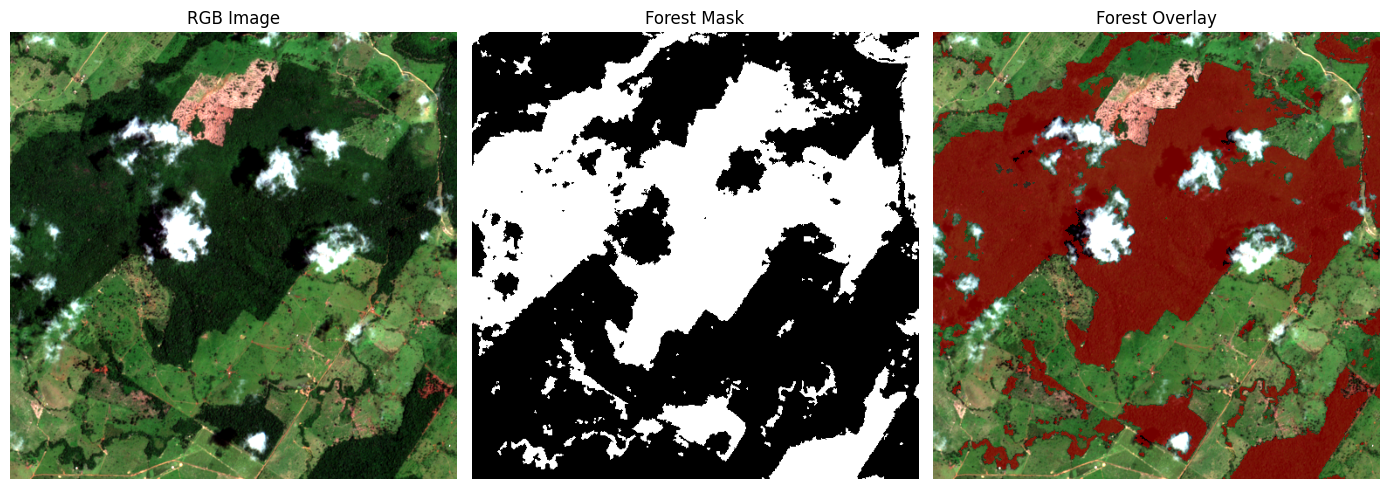

In [ ]:
import matplotlib.pyplot as plt


def enhance_rgb_for_display(image):
    lower = np.percentile(
        image,
        2,
        axis=(0, 1),
        keepdims=True,
    )

    upper = np.percentile(
        image,
        98,
        axis=(0, 1),
        keepdims=True,
    )

    enhanced = (
        image - lower
    ) / (
        upper - lower + 1e-8
    )

    return np.clip(
        enhanced,
        0.0,
        1.0,
    )


batch = next(
    iter(train_loader)
)

batch_images = batch["image"]
batch_masks = batch["mask"]


print("=" * 70)
print("BATCH VERIFICATION")
print("=" * 70)

print("Image batch shape:")
print(batch_images.shape)

print("\nMask batch shape:")
print(batch_masks.shape)

print("\nImage range:")
print(float(batch_images.min()), float(batch_images.max()))

print("\nMask values:")
print(torch.unique(batch_masks))


plt.figure(figsize=(14, 5))

image = batch_images[0].numpy()
image = np.moveaxis(
    image,
    0,
    -1,
)

rgb = enhance_rgb_for_display(image)

mask = batch_masks[0, 0].numpy()

overlay = rgb.copy()
forest_pixels = mask == 1

overlay[forest_pixels] = (
    0.55 * overlay[forest_pixels]
    + 0.45 * np.array([1.0, 0.0, 0.0])
)


plt.subplot(1, 3, 1)
plt.imshow(rgb)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    mask,
    cmap="gray",
    vmin=0,
    vmax=1,
)
plt.title("Forest Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Forest Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

## **15. Define SAMA Block-enhanced U-Net**

In [ ]:
from pathlib import Path
import sys
import importlib.util


REPO_DIR = Path("/content/SAMA-UNet")
MODEL_FILE = REPO_DIR / "model.py"


print("Repository exists:", REPO_DIR.exists())
print("model.py exists:", MODEL_FILE.exists())

if not MODEL_FILE.exists():
    raise FileNotFoundError(
        f"model.py was not found at:\n{MODEL_FILE}"
    )


# Load model.py directly from its file path
spec = importlib.util.spec_from_file_location(
    "sama_official_model",
    str(MODEL_FILE),
)

sama_official_model = importlib.util.module_from_spec(
    spec
)

spec.loader.exec_module(
    sama_official_model
)


# Make SAMA_Block available globally for later cells
SAMA_Block = sama_official_model.SAMA_Block


print("SAMA_Block imported successfully using direct file import.")
print("SAMA_Block:", SAMA_Block)

Repository exists: True
model.py exists: True
SAMA_Block imported successfully using direct file import.
SAMA_Block: <class 'sama_official_model.SAMA_Block'>


In [ ]:
%cd /content/SAMA-UNet

import sys
sys.path.append("/content/SAMA-UNet")

import torch.nn as nn
import torch.nn.functional as F

from model import SAMA_Block


class DoubleConv(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
    ):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(
                out_channels
            ),
            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(
                out_channels
            ),
            nn.ReLU(
                inplace=True
            ),
        )

    def forward(self, x):
        return self.layers(x)


class DownBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
    ):
        super().__init__()

        self.layers = nn.Sequential(
            nn.MaxPool2d(
                kernel_size=2,
                stride=2,
            ),
            DoubleConv(
                in_channels,
                out_channels,
            ),
        )

    def forward(self, x):
        return self.layers(x)


class UpBlock(nn.Module):
    def __init__(
        self,
        decoder_channels,
        skip_channels,
        output_channels,
    ):
        super().__init__()

        self.upsample = nn.ConvTranspose2d(
            decoder_channels,
            output_channels,
            kernel_size=2,
            stride=2,
        )

        self.convolution = DoubleConv(
            output_channels + skip_channels,
            output_channels,
        )

    def forward(
        self,
        decoder_feature,
        skip_feature,
    ):
        decoder_feature = self.upsample(
            decoder_feature
        )

        if decoder_feature.shape[-2:] != skip_feature.shape[-2:]:
            decoder_feature = F.interpolate(
                decoder_feature,
                size=skip_feature.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        combined_feature = torch.cat(
            [
                skip_feature,
                decoder_feature,
            ],
            dim=1,
        )

        return self.convolution(
            combined_feature
        )


class SAMABlockEnhancedUNet(nn.Module):
    """
    U-Net with the official SAMA_Block inserted after
    the bottleneck.

    Input:
        [batch, 3, 512, 512]

    Bottleneck:
        [batch, 512, 32, 32]

    Output:
        [batch, 1, 512, 512]
    """

    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        base_channels=32,
    ):
        super().__init__()

        c = base_channels

        self.encoder1 = DoubleConv(
            in_channels,
            c,
        )

        self.encoder2 = DownBlock(
            c,
            c * 2,
        )

        self.encoder3 = DownBlock(
            c * 2,
            c * 4,
        )

        self.encoder4 = DownBlock(
            c * 4,
            c * 8,
        )

        self.bottleneck = DownBlock(
            c * 8,
            c * 16,
        )

        self.sama_block = SAMA_Block(
            dim=c * 16,
            num_heads=8,
        )

        self.decoder1 = UpBlock(
            decoder_channels=c * 16,
            skip_channels=c * 8,
            output_channels=c * 8,
        )

        self.decoder2 = UpBlock(
            decoder_channels=c * 8,
            skip_channels=c * 4,
            output_channels=c * 4,
        )

        self.decoder3 = UpBlock(
            decoder_channels=c * 4,
            skip_channels=c * 2,
            output_channels=c * 2,
        )

        self.decoder4 = UpBlock(
            decoder_channels=c * 2,
            skip_channels=c,
            output_channels=c,
        )

        self.output_layer = nn.Conv2d(
            c,
            out_channels,
            kernel_size=1,
        )

    def forward(self, x):
        encoder1 = self.encoder1(x)
        encoder2 = self.encoder2(encoder1)
        encoder3 = self.encoder3(encoder2)
        encoder4 = self.encoder4(encoder3)

        bottleneck = self.bottleneck(
            encoder4
        )

        bottleneck = self.sama_block(
            bottleneck
        )

        decoder1 = self.decoder1(
            bottleneck,
            encoder4,
        )

        decoder2 = self.decoder2(
            decoder1,
            encoder3,
        )

        decoder3 = self.decoder3(
            decoder2,
            encoder2,
        )

        decoder4 = self.decoder4(
            decoder3,
            encoder1,
        )

        logits = self.output_layer(
            decoder4
        )

        return logits


print("SAMA Block-enhanced U-Net class created.")

/content/SAMA-UNet
SAMA Block-enhanced U-Net class created.


## **16. Create model and run smoke test**

In [ ]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()


model = SAMABlockEnhancedUNet(
    in_channels=IN_CHANNELS,
    out_channels=NUM_CLASSES,
    base_channels=BASE_CHANNELS,
).to(DEVICE)


total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


print("=" * 70)
print("SAMA BLOCK-ENHANCED U-NET SUMMARY")
print("=" * 70)

print("Device:", DEVICE)
print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")


dummy_input = torch.randn(
    1,
    IN_CHANNELS,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=DEVICE,
)


model.eval()

with torch.inference_mode():
    dummy_output = model(
        dummy_input
    )


print("\nDummy input shape:")
print(dummy_input.shape)

print("\nDummy output shape:")
print(dummy_output.shape)


assert dummy_output.shape == (
    1,
    1,
    IMAGE_SIZE,
    IMAGE_SIZE,
)


print("\nModel smoke test passed.")


del dummy_input
del dummy_output

if torch.cuda.is_available():
    torch.cuda.empty_cache()

SAMA BLOCK-ENHANCED U-NET SUMMARY
Device: cuda
Total parameters: 11,581,027
Trainable parameters: 11,581,027

Dummy input shape:
torch.Size([1, 3, 512, 512])

Dummy output shape:
torch.Size([1, 1, 512, 512])

Model smoke test passed.


## **17. Define BCE + Dice loss**

In [ ]:
import torch
import torch.nn as nn


binary_cross_entropy_loss = nn.BCEWithLogitsLoss()


def soft_dice_loss(
    logits,
    targets,
    smooth=1.0,
):
    probabilities = torch.sigmoid(logits)

    probabilities = probabilities.reshape(
        probabilities.shape[0],
        -1,
    )

    targets = targets.reshape(
        targets.shape[0],
        -1,
    )

    intersection = (
        probabilities * targets
    ).sum(dim=1)

    dice_score = (
        2.0 * intersection + smooth
    ) / (
        probabilities.sum(dim=1)
        + targets.sum(dim=1)
        + smooth
    )

    return 1.0 - dice_score.mean()


def combined_segmentation_loss(
    logits,
    targets,
):
    bce_loss = binary_cross_entropy_loss(
        logits,
        targets,
    )

    dice_loss = soft_dice_loss(
        logits,
        targets,
    )

    total_loss = (
        BCE_WEIGHT * bce_loss
        + DICE_WEIGHT * dice_loss
    )

    return total_loss


print("Combined BCE + Dice loss created.")
print("BCE weight:", BCE_WEIGHT)
print("Dice weight:", DICE_WEIGHT)

Combined BCE + Dice loss created.
BCE weight: 0.5
Dice weight: 0.5


## **18. Define segmentation metrics**

In [ ]:
def calculate_confusion_counts(
    logits,
    targets,
    threshold=0.5,
):
    probabilities = torch.sigmoid(logits)

    predictions = probabilities >= threshold
    targets = targets >= 0.5

    true_positive = (
        predictions & targets
    ).sum().item()

    false_positive = (
        predictions & ~targets
    ).sum().item()

    false_negative = (
        ~predictions & targets
    ).sum().item()

    true_negative = (
        ~predictions & ~targets
    ).sum().item()

    return {
        "tp": float(true_positive),
        "fp": float(false_positive),
        "fn": float(false_negative),
        "tn": float(true_negative),
    }


def calculate_metrics_from_counts(
    tp,
    fp,
    fn,
    tn,
):
    epsilon = 1e-8

    accuracy = (
        tp + tn
    ) / (
        tp + tn + fp + fn + epsilon
    )

    precision = tp / (
        tp + fp + epsilon
    )

    recall = tp / (
        tp + fn + epsilon
    )

    specificity = tn / (
        tn + fp + epsilon
    )

    f1_score = (
        2.0 * tp
    ) / (
        2.0 * tp + fp + fn + epsilon
    )

    iou = tp / (
        tp + fp + fn + epsilon
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1_score,
        "iou": iou,
    }


print("Segmentation metric functions created.")

Segmentation metric functions created.


## **19. Optimizer, scheduler and mixed precision**

In [ ]:
from contextlib import nullcontext


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=LR_REDUCTION_FACTOR,
    patience=LR_PATIENCE,
)


USE_AMP = DEVICE.type == "cuda"


try:
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )

except (TypeError, AttributeError):
    scaler = torch.cuda.amp.GradScaler(
        enabled=USE_AMP,
    )


def autocast_context():
    if USE_AMP:
        return torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        )

    return nullcontext()


print("=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)

print("Optimizer: AdamW")
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Mixed precision:", USE_AMP)
print("Batch size:", BATCH_SIZE)
print("Gradient accumulation:", ACCUMULATION_STEPS)
print("Effective batch size:", BATCH_SIZE * ACCUMULATION_STEPS)

TRAINING CONFIGURATION
Optimizer: AdamW
Learning rate: 0.0001
Weight decay: 1e-05
Mixed precision: True
Batch size: 2
Gradient accumulation: 2
Effective batch size: 4


## **20. Forward/backward smoke test**

In [ ]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()


model.train()

optimizer.zero_grad(
    set_to_none=True,
)


smoke_batch = next(
    iter(train_loader)
)


smoke_images = smoke_batch["image"].to(
    DEVICE,
    non_blocking=True,
)


smoke_masks = smoke_batch["mask"].to(
    DEVICE,
    non_blocking=True,
)


with autocast_context():
    smoke_logits = model(
        smoke_images
    )

    smoke_loss = combined_segmentation_loss(
        smoke_logits,
        smoke_masks,
    )


scaler.scale(
    smoke_loss
).backward()


smoke_counts = calculate_confusion_counts(
    smoke_logits.detach(),
    smoke_masks,
    threshold=THRESHOLD,
)


smoke_metrics = calculate_metrics_from_counts(
    **smoke_counts
)


print("=" * 70)
print("SAMA BLOCK MODEL FORWARD/BACKWARD SMOKE TEST")
print("=" * 70)

print("Input shape:")
print(smoke_images.shape)

print("\nTarget shape:")
print(smoke_masks.shape)

print("\nOutput shape:")
print(smoke_logits.shape)

print("\nInitial loss:")
print(float(smoke_loss.detach().cpu()))

print("\nInitial random-weight metrics:")

for metric_name, metric_value in smoke_metrics.items():
    print(
        f"{metric_name}: {metric_value:.6f}"
    )


assert smoke_logits.shape == smoke_masks.shape
assert torch.isfinite(smoke_loss)


optimizer.zero_grad(
    set_to_none=True,
)


del smoke_batch
del smoke_images
del smoke_masks
del smoke_logits
del smoke_loss


if torch.cuda.is_available():
    torch.cuda.empty_cache()


print(
    "\nSmoke test completed successfully. "
    "The SAMA Block-enhanced U-Net is ready for full training."
)

SAMA BLOCK MODEL FORWARD/BACKWARD SMOKE TEST
Input shape:
torch.Size([2, 3, 512, 512])

Target shape:
torch.Size([2, 1, 512, 512])

Output shape:
torch.Size([2, 1, 512, 512])

Initial loss:
0.5951592922210693

Initial random-weight metrics:
accuracy: 0.574886
precision: 0.665153
recall: 0.640321
specificity: 0.466612
f1: 0.652501
iou: 0.484231

Smoke test completed successfully. The SAMA Block-enhanced U-Net is ready for full training.


## **20 B. Reset model for clean training**

In [ ]:
import os
import random
import time
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch


def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


if "SAMA_Block" not in globals():
    raise RuntimeError(
        "SAMA_Block is missing. Run the fixed Cell 15A again."
    )


if torch.cuda.is_available():
    torch.cuda.empty_cache()


model = SAMABlockEnhancedUNet(
    in_channels=IN_CHANNELS,
    out_channels=NUM_CLASSES,
    base_channels=BASE_CHANNELS,
).to(DEVICE)


total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=LR_REDUCTION_FACTOR,
    patience=LR_PATIENCE,
)


USE_AMP = DEVICE.type == "cuda"


try:
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )

except (TypeError, AttributeError):
    scaler = torch.cuda.amp.GradScaler(
        enabled=USE_AMP,
    )


def autocast_context():
    if USE_AMP:
        return torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        )

    return nullcontext()


print("=" * 70)
print("CLEAN SAMA BLOCK TRAINING STATE INITIALIZED")
print("=" * 70)

print("Model: SAMA Block-enhanced U-Net")
print("Device:", DEVICE)
print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")
print("Output directory:", DRIVE_OUTPUT_DIR)
print("Mixed precision:", USE_AMP)
print("Learning rate:", optimizer.param_groups[0]["lr"])

CLEAN SAMA BLOCK TRAINING STATE INITIALIZED
Model: SAMA Block-enhanced U-Net
Device: cuda
Total parameters: 11,581,027
Trainable parameters: 11,581,027
Output directory: /content/drive/MyDrive/ForestResearch/Results/SAMA_Block_Enhanced_UNet_Original
Mixed precision: True
Learning rate: 0.0001


## **21. Training and evaluation functions**

### **21 A. Stable DataLoader settings**

In [ ]:
NUM_EPOCHS = 50

NUM_WORKERS = 0

BATCH_SIZE = 2
ACCUMULATION_STEPS = 2

print("Updated training settings:")
print("Maximum epochs:", NUM_EPOCHS)
print("Number of workers:", NUM_WORKERS)
print("Batch size:", BATCH_SIZE)
print("Effective batch size:", BATCH_SIZE * ACCUMULATION_STEPS)

Updated training settings:
Maximum epochs: 50
Number of workers: 0
Batch size: 2
Effective batch size: 4


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=False,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=False,
)

print("=" * 70)
print("STABLE DATALOADERS CREATED")
print("=" * 70)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))
print("NUM_WORKERS:", NUM_WORKERS)

STABLE DATALOADERS CREATED
Training samples: 1123
Validation samples: 100
Test samples: 100
Training batches: 562
Validation batches: 50
Test batches: 50
NUM_WORKERS: 0


In [ ]:
from tqdm.auto import tqdm


def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    optimizer.zero_grad(
        set_to_none=True
    )

    progress_bar = tqdm(
        enumerate(loader),
        total=len(loader),
        desc="Training",
        leave=False,
    )

    for batch_index, batch in progress_bar:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        masks = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        )

        with autocast_context():
            logits = model(images)

            loss = combined_segmentation_loss(
                logits,
                masks,
            )

            backward_loss = (
                loss / ACCUMULATION_STEPS
            )

        scaler.scale(
            backward_loss
        ).backward()

        accumulation_complete = (
            (batch_index + 1)
            % ACCUMULATION_STEPS
            == 0
        )

        final_batch = (
            batch_index + 1
            == len(loader)
        )

        if accumulation_complete or final_batch:
            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=GRADIENT_CLIP_NORM,
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )

        batch_size = images.shape[0]

        total_loss += (
            float(loss.detach().cpu())
            * batch_size
        )

        total_samples += batch_size

        progress_bar.set_postfix(
            loss=f"{float(loss.detach().cpu()):.4f}"
        )

    return total_loss / max(total_samples, 1)


@torch.inference_mode()
def evaluate_model(
    model,
    loader,
    threshold=0.5,
    description="Evaluation",
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0

    progress_bar = tqdm(
        loader,
        desc=description,
        leave=False,
    )

    for batch in progress_bar:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        masks = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        )

        with autocast_context():
            logits = model(images)

            loss = combined_segmentation_loss(
                logits,
                masks,
            )

        batch_size = images.shape[0]

        total_loss += (
            float(loss.detach().cpu())
            * batch_size
        )

        total_samples += batch_size

        counts = calculate_confusion_counts(
            logits,
            masks,
            threshold=threshold,
        )

        total_tp += counts["tp"]
        total_fp += counts["fp"]
        total_fn += counts["fn"]
        total_tn += counts["tn"]

    metrics = calculate_metrics_from_counts(
        tp=total_tp,
        fp=total_fp,
        fn=total_fn,
        tn=total_tn,
    )

    metrics["loss"] = total_loss / max(total_samples, 1)
    metrics["tp"] = total_tp
    metrics["fp"] = total_fp
    metrics["fn"] = total_fn
    metrics["tn"] = total_tn

    return metrics


print("Training and evaluation functions created.")

Training and evaluation functions created.


## **22. Full training loop**

In [ ]:
BEST_MODEL_PATH = (
    CHECKPOINT_DIR
    / "sama_block_enhanced_unet_best_validation_iou.pth"
)

LAST_MODEL_PATH = (
    CHECKPOINT_DIR
    / "sama_block_enhanced_unet_last_checkpoint.pth"
)

HISTORY_CSV_PATH = (
    LOG_DIR
    / "sama_block_enhanced_unet_training_history.csv"
)


history = []

best_validation_iou = -1.0
best_epoch = 0
epochs_without_improvement = 0

training_start_time = time.perf_counter()


print("=" * 70)
print("STARTING SAMA BLOCK-ENHANCED U-NET TRAINING")
print("=" * 70)

print("Maximum epochs:", NUM_EPOCHS)
print("Early-stopping patience:", EARLY_STOPPING_PATIENCE)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Effective batch size:", BATCH_SIZE * ACCUMULATION_STEPS)
print("Best checkpoint:", BEST_MODEL_PATH)


for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start_time = time.perf_counter()

    print("\n" + "=" * 70)
    print(f"EPOCH {epoch}/{NUM_EPOCHS}")
    print("=" * 70)

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        scaler=scaler,
    )

    validation_metrics = evaluate_model(
        model=model,
        loader=validation_loader,
        threshold=THRESHOLD,
        description="Validation",
    )

    scheduler.step(
        validation_metrics["iou"]
    )

    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    epoch_seconds = (
        time.perf_counter()
        - epoch_start_time
    )

    improved = (
        validation_metrics["iou"]
        > best_validation_iou
    )

    if improved:
        best_validation_iou = validation_metrics["iou"]
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": validation_metrics["loss"],
        "val_accuracy": validation_metrics["accuracy"],
        "val_precision": validation_metrics["precision"],
        "val_recall": validation_metrics["recall"],
        "val_specificity": validation_metrics["specificity"],
        "val_f1": validation_metrics["f1"],
        "val_iou": validation_metrics["iou"],
        "learning_rate": current_learning_rate,
        "epoch_seconds": epoch_seconds,
    }

    history.append(epoch_record)

    pd.DataFrame(history).to_csv(
        HISTORY_CSV_PATH,
        index=False,
    )

    checkpoint = {
        "epoch": epoch,
        "best_epoch": best_epoch,
        "model_name": "SAMA_Block_Enhanced_UNet",
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_validation_iou": best_validation_iou,
        "epochs_without_improvement": epochs_without_improvement,
        "history": history,
        "configuration": {
            "seed": SEED,
            "input_channels": IN_CHANNELS,
            "band_indices": BAND_INDICES,
            "forest_class_value": FOREST_CLASS_VALUE,
            "background_class_value": BACKGROUND_CLASS_VALUE,
            "image_size": IMAGE_SIZE,
            "base_channels": BASE_CHANNELS,
            "batch_size": BATCH_SIZE,
            "accumulation_steps": ACCUMULATION_STEPS,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "bce_weight": BCE_WEIGHT,
            "dice_weight": DICE_WEIGHT,
            "threshold": THRESHOLD,
            "total_parameters": total_parameters,
            "trainable_parameters": trainable_parameters,
            "sama_block_location": "bottleneck",
            "sama_block_dim": BASE_CHANNELS * 16,
            "sama_block_num_heads": 8,
        },
    }

    torch.save(
        checkpoint,
        LAST_MODEL_PATH,
    )

    if improved:
        torch.save(
            checkpoint,
            BEST_MODEL_PATH,
        )

    print(f"Train loss:       {train_loss:.6f}")
    print(f"Validation loss:  {validation_metrics['loss']:.6f}")
    print(f"Accuracy:         {validation_metrics['accuracy']:.6f}")
    print(f"Precision:        {validation_metrics['precision']:.6f}")
    print(f"Recall:           {validation_metrics['recall']:.6f}")
    print(f"Specificity:      {validation_metrics['specificity']:.6f}")
    print(f"F1 / Dice:        {validation_metrics['f1']:.6f}")
    print(f"IoU:              {validation_metrics['iou']:.6f}")
    print(f"Learning rate:    {current_learning_rate:.8f}")
    print(f"Epoch time:       {epoch_seconds:.2f} seconds")

    if improved:
        print(
            f"New best checkpoint saved at epoch {epoch}."
        )
    else:
        print(
            "Epochs without validation-IoU improvement:",
            epochs_without_improvement,
        )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping activated.")
        break


total_training_seconds = (
    time.perf_counter()
    - training_start_time
)


print("\n" + "=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)

print("Best epoch:", best_epoch)
print("Best validation IoU:", f"{best_validation_iou:.6f}")
print("Total training time:", f"{total_training_seconds / 60:.2f} minutes")

print("\nBest checkpoint:")
print(BEST_MODEL_PATH)

print("\nLatest checkpoint:")
print(LAST_MODEL_PATH)

print("\nTraining history:")
print(HISTORY_CSV_PATH)

STARTING SAMA BLOCK-ENHANCED U-NET TRAINING
Maximum epochs: 50
Early-stopping patience: 15
Training samples: 1123
Validation samples: 100
Effective batch size: 4
Best checkpoint: /content/drive/MyDrive/ForestResearch/Results/SAMA_Block_Enhanced_UNet_Original/checkpoints/sama_block_enhanced_unet_best_validation_iou.pth

EPOCH 1/50


Training:   0%|          | 0/562 [00:00<?, ?it/s]

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train loss:       0.339380
Validation loss:  0.224138
Accuracy:         0.925839
Precision:        0.903440
Recall:           0.979939
Specificity:      0.846605
F1 / Dice:        0.940136
IoU:              0.887035
Learning rate:    0.00010000
Epoch time:       76.99 seconds
New best checkpoint saved at epoch 1.

EPOCH 2/50


Training:   0%|          | 0/562 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train loss:       0.107347
Validation loss:  0.102802
Accuracy:         0.957125
Precision:        0.946376
Recall:           0.983583
Specificity:      0.918374
F1 / Dice:        0.964621
IoU:              0.931660
Learning rate:    0.00001250
Epoch time:       80.53 seconds
Epochs without validation-IoU improvement: 1

EPOCH 50/50


Training:   0%|          | 0/562 [00:00<?, ?it/s]

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train loss:       0.105708
Validation loss:  0.104312
Accuracy:         0.957850
Precision:        0.949641
Recall:           0.981098
Specificity:      0.923801
F1 / Dice:        0.965113
IoU:              0.932579
Learning rate:    0.00001250
Epoch time:       78.49 seconds
Epochs without validation-IoU improvement: 2

TRAINING COMPLETED
Best epoch: 48
Best validation IoU: 0.949298
Total training time: 65.53 minutes

Best checkpoint:
/content/drive/MyDrive/ForestResearch/Results/SAMA_Block_Enhanced_UNet_Original/checkpoints/sama_block_enhanced_unet_best_validation_iou.pth

Latest checkpoint:
/content/drive/MyDrive/ForestResearch/Results/SAMA_Block_Enhanced_UNet_Original/checkpoints/sama_block_enhanced_unet_last_checkpoint.pth

Training history:
/content/drive/MyDrive/ForestResearch/Results/SAMA_Block_Enhanced_UNet_Original/logs/sama_block_enhanced_unet_training_history.csv


Load the best SAMA Block model

In [ ]:
BEST_MODEL_PATH = (
    CHECKPOINT_DIR
    / "sama_block_enhanced_unet_best_validation_iou.pth"
)

print("Best checkpoint exists:", BEST_MODEL_PATH.exists())
print("Best checkpoint path:", BEST_MODEL_PATH)

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Best checkpoint not found:\n{BEST_MODEL_PATH}"
    )


checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False,
)


model = SAMABlockEnhancedUNet(
    in_channels=IN_CHANNELS,
    out_channels=NUM_CLASSES,
    base_channels=BASE_CHANNELS,
).to(DEVICE)


model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()


print("=" * 70)
print("BEST SAMA BLOCK MODEL LOADED")
print("=" * 70)

print("Model name:", checkpoint.get("model_name", "SAMA_Block_Enhanced_UNet"))
print("Best epoch:", checkpoint["best_epoch"])
print("Best validation IoU:", checkpoint["best_validation_iou"])
print("Threshold:", THRESHOLD)

Best checkpoint exists: True
Best checkpoint path: /content/drive/MyDrive/ForestResearch/Results/SAMA_Block_Enhanced_UNet_Original/checkpoints/sama_block_enhanced_unet_best_validation_iou.pth
BEST SAMA BLOCK MODEL LOADED
Model name: SAMA_Block_Enhanced_UNet
Best epoch: 48
Best validation IoU: 0.9492983294657347
Threshold: 0.5


Evaluate on validation and test sets

In [ ]:
final_validation_metrics = evaluate_model(
    model=model,
    loader=validation_loader,
    threshold=THRESHOLD,
    description="Final Validation",
)

final_test_metrics = evaluate_model(
    model=model,
    loader=test_loader,
    threshold=THRESHOLD,
    description="Final Test",
)


final_metrics_table = pd.DataFrame(
    [
        {
            "split": "validation",
            "loss": final_validation_metrics["loss"],
            "accuracy": final_validation_metrics["accuracy"],
            "precision": final_validation_metrics["precision"],
            "recall": final_validation_metrics["recall"],
            "specificity": final_validation_metrics["specificity"],
            "f1_dice": final_validation_metrics["f1"],
            "iou": final_validation_metrics["iou"],
        },
        {
            "split": "test",
            "loss": final_test_metrics["loss"],
            "accuracy": final_test_metrics["accuracy"],
            "precision": final_test_metrics["precision"],
            "recall": final_test_metrics["recall"],
            "specificity": final_test_metrics["specificity"],
            "f1_dice": final_test_metrics["f1"],
            "iou": final_test_metrics["iou"],
        },
    ]
)


FINAL_METRICS_PATH = (
    LOG_DIR
    / "sama_block_enhanced_unet_final_metrics.csv"
)


final_metrics_table.to_csv(
    FINAL_METRICS_PATH,
    index=False,
)


print("=" * 70)
print("FINAL SAMA BLOCK MODEL RESULTS")
print("=" * 70)

display(final_metrics_table)

print("\nFinal metrics saved to:")
print(FINAL_METRICS_PATH)

Final Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Final Test:   0%|          | 0/50 [00:00<?, ?it/s]

FINAL SAMA BLOCK MODEL RESULTS


,split,loss,accuracy,precision,recall,specificity,f1_dice,iou
0,validation,0.070084,0.968982,0.970727,0.977274,0.956838,0.973990,0.949298
1,test,0.087309,0.970997,0.967932,0.979776,0.960243,0.973818,0.948972



Final metrics saved to:
/content/drive/MyDrive/ForestResearch/Results/SAMA_Block_Enhanced_UNet_Original/logs/sama_block_enhanced_unet_final_metrics.csv


Plot training curves

History rows: 50


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_specificity,val_f1,val_iou,learning_rate,epoch_seconds
45,46,0.108403,0.085956,0.963936,0.962441,0.977456,0.944134,0.969891,0.941541,0.000013,79.073865
46,47,0.106886,0.083681,0.963307,0.964580,0.974020,0.947616,0.969277,0.940385,0.000013,78.407741
47,48,0.108675,0.070084,0.968982,0.970727,0.977274,0.956838,0.973990,0.949298,0.000013,78.097593
48,49,0.107347,0.102802,0.957125,0.946376,0.983583,0.918374,0.964621,0.931660,0.000013,80.528401
49,50,0.105708,0.104312,0.957850,0.949641,0.981098,0.923801,0.965113,0.932579,0.000013,78.488795


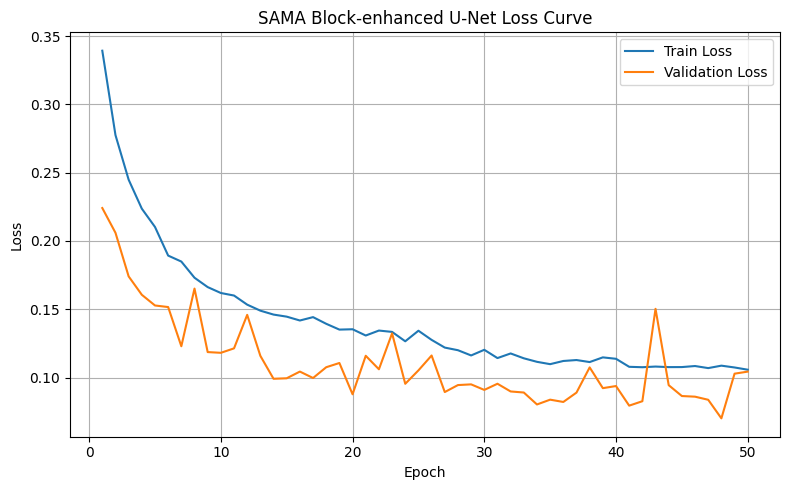

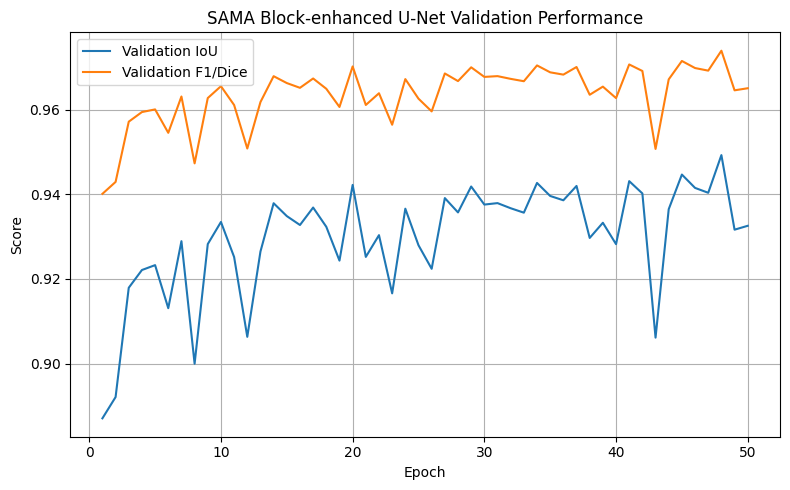

Loss curve saved to:
/content/drive/MyDrive/ForestResearch/Results/SAMA_Block_Enhanced_UNet_Original/figures/sama_block_loss_curve.png

Metric curve saved to:
/content/drive/MyDrive/ForestResearch/Results/SAMA_Block_Enhanced_UNet_Original/figures/sama_block_metric_curve.png


In [ ]:
import matplotlib.pyplot as plt


history_df = pd.read_csv(
    HISTORY_CSV_PATH
)


print("History rows:", len(history_df))
display(history_df.tail())


plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SAMA Block-enhanced U-Net Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

LOSS_CURVE_PATH = FIGURE_DIR / "sama_block_loss_curve.png"

plt.savefig(
    LOSS_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_iou"], label="Validation IoU")
plt.plot(history_df["epoch"], history_df["val_f1"], label="Validation F1/Dice")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("SAMA Block-enhanced U-Net Validation Performance")
plt.legend()
plt.grid(True)
plt.tight_layout()

METRIC_CURVE_PATH = FIGURE_DIR / "sama_block_metric_curve.png"

plt.savefig(
    METRIC_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("Loss curve saved to:")
print(LOSS_CURVE_PATH)

print("\nMetric curve saved to:")
print(METRIC_CURVE_PATH)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


SAMPLE_PREDICTION_DIR = (
    PREDICTION_DIR
    / "sample_test_predictions"
)

SAMPLE_PREDICTION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


@torch.inference_mode()
def save_sample_predictions(
    model,
    loader,
    output_dir,
    max_samples=10,
    threshold=0.5,
):
    model.eval()

    saved_count = 0

    for batch in loader:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        masks = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        )

        with autocast_context():
            logits = model(images)

        probabilities = torch.sigmoid(
            logits
        )

        predictions = (
            probabilities >= threshold
        ).float()

        images_cpu = images.detach().cpu()
        masks_cpu = masks.detach().cpu()
        predictions_cpu = predictions.detach().cpu()
        probabilities_cpu = probabilities.detach().cpu()

        batch_size = images_cpu.shape[0]

        for index in range(batch_size):
            if saved_count >= max_samples:
                return

            image = images_cpu[index].numpy()
            image = np.moveaxis(
                image,
                0,
                -1,
            )

            rgb = enhance_rgb_for_display(
                image
            )

            ground_truth = masks_cpu[index, 0].numpy()
            prediction = predictions_cpu[index, 0].numpy()
            probability = probabilities_cpu[index, 0].numpy()

            overlay = rgb.copy()
            predicted_pixels = prediction == 1

            overlay[predicted_pixels] = (
                0.55 * overlay[predicted_pixels]
                + 0.45 * np.array([1.0, 0.0, 0.0])
            )

            plt.figure(figsize=(16, 4))

            plt.subplot(1, 4, 1)
            plt.imshow(rgb)
            plt.title("RGB Image")
            plt.axis("off")

            plt.subplot(1, 4, 2)
            plt.imshow(
                ground_truth,
                cmap="gray",
                vmin=0,
                vmax=1,
            )
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(1, 4, 3)
            plt.imshow(
                prediction,
                cmap="gray",
                vmin=0,
                vmax=1,
            )
            plt.title("Prediction")
            plt.axis("off")

            plt.subplot(1, 4, 4)
            plt.imshow(overlay)
            plt.title("Prediction Overlay")
            plt.axis("off")

            plt.tight_layout()

            save_path = (
                output_dir
                / f"sama_block_prediction_{saved_count + 1:02d}.png"
            )

            plt.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight",
            )

            plt.show()
            plt.close()

            saved_count += 1


save_sample_predictions(
    model=model,
    loader=test_loader,
    output_dir=SAMPLE_PREDICTION_DIR,
    max_samples=10,
    threshold=THRESHOLD,
)


print("Sample predictions saved to:")
print(SAMPLE_PREDICTION_DIR)

NameError: name 'PREDICTION_DIR' is not defined